### What is Routing in LangGraph?
#### Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically using:
- add_conditional_edges: A method that maps a node's output (or a condition function's resuylt) to different possible next nodes
- State: The workflow's state can store variables that influence routing decisions 
- Condition Functions: Functions that evaluate the state or node output to decide the next step

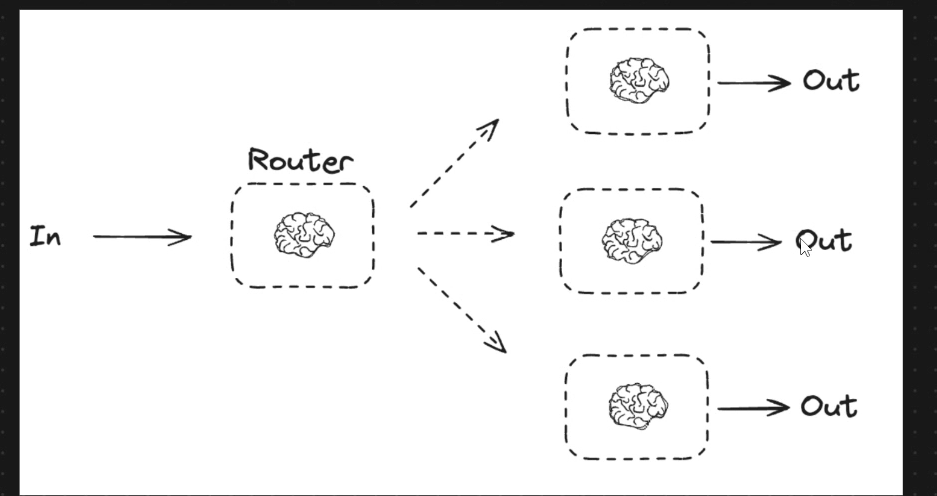
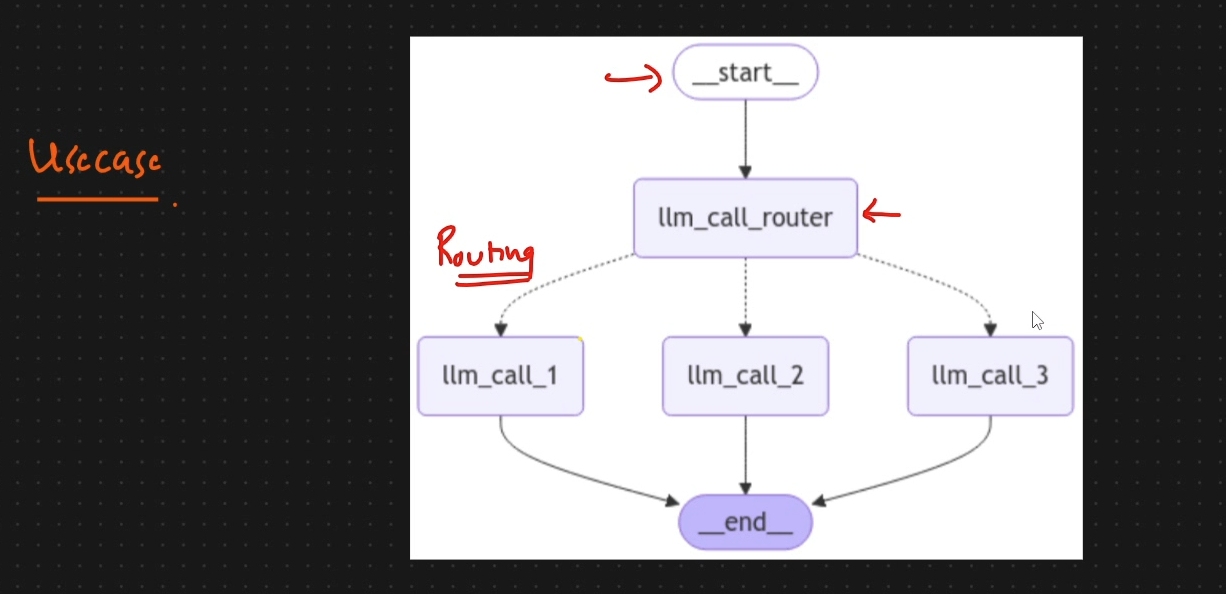

### Key concepts:
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results 
- Condition Logic: You define rules (eg: "if this, go here; if that, go there")
- Flexibility: Combines well with parallelization or sequential chains for complex workflows



In [ ]:
# load LLM
import os
from dotenv import load_dotenv
load_dotenv(".env")
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"]="gsk_XXXXX"
print(os.getenv("GROQ_API_KEY"))

llm=ChatGroq(model="qwen/qwen3-32b")
# if OPENAI use below LLM 
# llm=ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

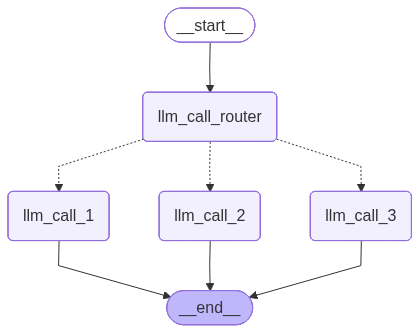

In [33]:
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage,SystemMessage 
from typing_extensions import TypedDict

# This is the schema for the structured output to use as a routing logic
class Route(BaseModel):
    step:Literal["story","joke","poem"]=Field(description="The next step in the routing process")

# Augment the LLM with schema for the structured output
router=llm.with_structured_output(Route)

# Define a state class 
class State(TypedDict):
    input:str
    decision:str
    output:str

# Define nodes 
def llm_call_1(state:State):
    """Write a story"""
    print("LLM call 1 is called")
    result=llm.invoke(state["input"])
    return {"output":result.content}

def llm_call_2(state:State):
    """Write a joke"""
    print("LLM call 2 is called")
    result=llm.invoke(state["input"])
    return {"output":result.content}

def llm_call_3(state:State):
    """Write a poem"""
    print("LLM call 3 is called")
    result=llm.invoke(state["input"])
    return {"output":result.content}

def llm_call_router(state:State):
    """Route the input to the appropriate node"""
    decision=router.invoke(
        [
            SystemMessage(
                content="Route the input to story,joke or peom based on the user's request"
            ),
            HumanMessage(content=state["input"])
        ]
    )
    return {"decision":decision.step}


# Now, conditional edge function to route the appropriate node 
def route_decision(state:State):
    # Return the node name you want to visit next 
    if state["decision"]=="story":
        return "llm_call_1"
    elif state["decision"]=="joke":
        return "llm_call_2"
    elif state["decision"]=="poem":
        return "llm_call_3"

# Build the workflow 
# !pip install langgraph
from langgraph.graph import StateGraph, START,END 
from IPython.display import Image,display 
router_builder=StateGraph(State)
# add nodes 
router_builder.add_node("llm_call_1",llm_call_1)
router_builder.add_node("llm_call_2",llm_call_2)
router_builder.add_node("llm_call_3",llm_call_3)
router_builder.add_node("llm_call_router",llm_call_router)

# Add edges to connect nodes 
router_builder.add_edge(START,"llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        # name returned by route_decision: Name of the next node to visi
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3"
    }, 
)

router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile the workflow 
router_workflow=router_builder.compile()

# Show the workflow 
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [34]:
state=router_workflow.invoke({"input":"Write me a poem about Agentic AI System"})
print(state["output"])

LLM call 3 is called
<think>
Okay, the user wants a poem about an Agentic AI System. Let me start by understanding what exactly an Agentic AI is. From what I know, it's an AI that operates with a certain level of autonomy, making decisions and taking actions based on its programming and data. I need to highlight its autonomy, decision-making processes, and maybe its interactions with humans or other systems.

First, I should brainstorm some key themes: autonomy, learning, adaptability, collaboration with humans, ethical considerations, and the future implications. Maybe use metaphors related to consciousness or agency without making it too human-like. Words like "mind," "thought," "choices" could work but need to be framed correctly to avoid anthropomorphizing too much.

Structure-wise, maybe go with a traditional poem structure with stanzas and rhyme. Let me think about the flow. Start with introducing the system, then its capabilities, how it learns, interacts, possible challenges or